## Phase 02: Data Understanding & Visualization

Exploratory data analysis (EDA) and visualizations on the cleaned SMS Spam dataset to understand class distribution, message characteristics, and patterns that inform model selection.

In [4]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent  

from src.preprocessing import load_splits
df_train, df_val, df_test = load_splits()

print(df_train.shape, df_val.shape, df_test.shape)


(3093, 5) (1031, 5) (1032, 5)


### 2_1.Analyze class distribution

In [5]:
# Class distribution (spam vs. ham)
class_counts = df_train['Class'].value_counts()
print("Class distribution:")
print(class_counts)
print(f"\nRatio (ham/spam): {class_counts['ham'] / class_counts['spam']:.1f}")

Class distribution:
ham     2708
spam     385
Name: Class, dtype: int64

Ratio (ham/spam): 7.0


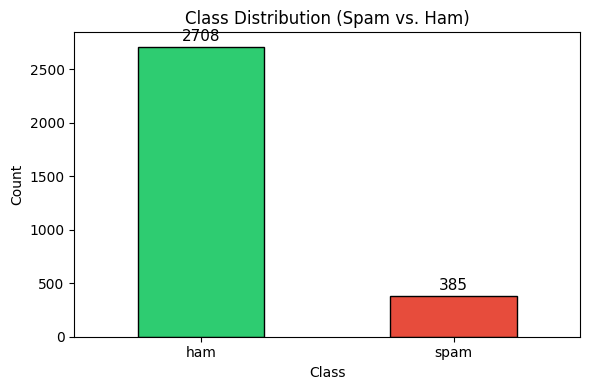

In [6]:
# Bar chart: Class distribution
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 4))
class_counts.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], edgecolor='black')
ax.set_title('Class Distribution (Spam vs. Ham)', fontsize=12)
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for i, v in enumerate(class_counts):
    ax.text(i, v + 50, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.show()

#### Results of Step 2_1. Data Understanding & Visualization

The dataset is imbalanced (ham: 2708, spam: 385; ratio ≈ 7:1).  


### 2_2. Visualize message length distribution (characters, words) for each class
Visualize message length in characters and in word count for ham vs. spam (histogram and box plot).

In [7]:
# Message length: characters and word count (using normalized text)
df_train['msg_len_chars'] = df_train['message_normalized'].str.len()
df_train['msg_len_words'] = df_train['message_normalized'].str.split().str.len()

print("Message length (chars) by class:")
print(df_train.groupby('Class')['msg_len_chars'].agg(['mean', 'median', 'std']))
print("\nMessage length (words) by class:")
print(df_train.groupby('Class')['msg_len_words'].agg(['mean', 'median', 'std']))



Message length (chars) by class:
             mean  median        std
Class                               
ham     64.969350    48.0  49.835876
spam   113.576623   120.0  25.325279

Message length (words) by class:
            mean  median        std
Class                              
ham    13.579025    10.0  10.076950
spam   21.051948    22.0   5.510161


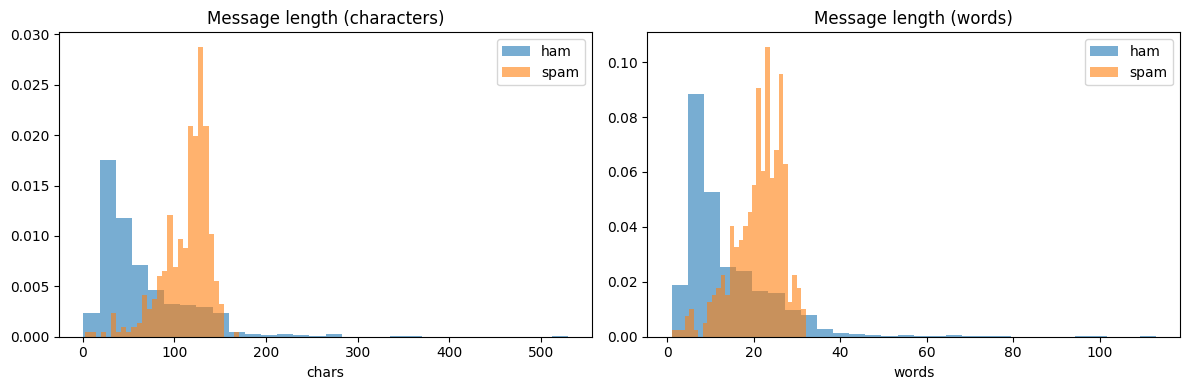

In [8]:
# Histogram: message length (characters) by class
from matplotlib import pyplot as plt


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in zip(axes, ['msg_len_chars', 'msg_len_words'],
                          ['Message length (characters)', 'Message length (words)']):
    for cls in ['ham', 'spam']:
        subset = df_train.loc[df_train['Class'] == cls, col].dropna() # type: ignore
        ax.hist(subset, bins=30, alpha=0.6, label=cls, density=True)
    ax.set_title(title)
    ax.set_xlabel(col.replace('msg_len_', ''))
    ax.legend()
plt.tight_layout()
plt.show()

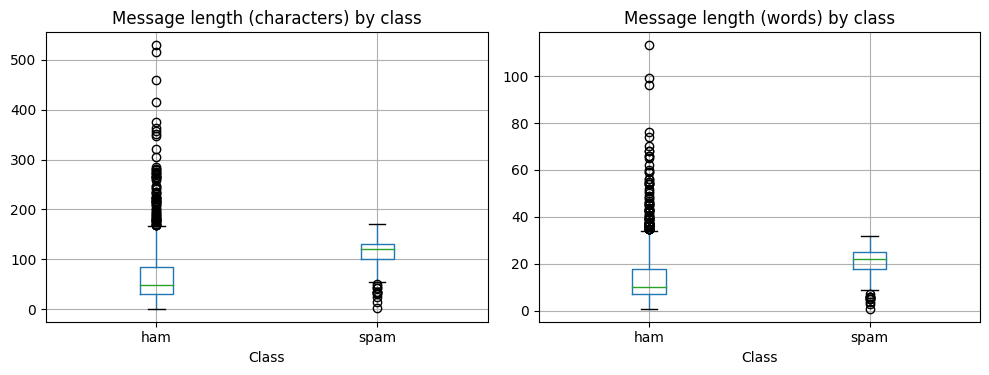

In [9]:
# Box plot: message length comparison (characters and words) by class
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df_train.boxplot(column='msg_len_chars', by='Class', ax=axes[0])
axes[0].set_title('Message length (characters) by class')
axes[0].set_xlabel('Class')
df_train.boxplot(column='msg_len_words', by='Class', ax=axes[1])
axes[1].set_title('Message length (words) by class')
axes[1].set_xlabel('Class')
plt.suptitle('')
plt.tight_layout()
plt.show()

#### Results of Step 2_2. Message Length Analysis

- **Spam messages are generally longer than ham messages.**  
  Both the mean and median message lengths (in characters and words) are higher for spam messages. Spam messages have a median length of approximately 120 characters and 22 words, whereas ham messages have a median length of about 48 characters and 10 words.

- **Ham messages show greater variability in length.**  
  The standard deviation of message length is significantly higher for ham messages, indicating a wider range of message lengths and the presence of more extreme outliers.

- **Spam messages have more consistent length patterns.**  
  Lower standard deviation values for spam messages suggest that their lengths are more tightly clustered around the median, likely due to standardized promotional templates.

- **Message length distributions differ in skewness.**  
  Ham message lengths are right-skewed, with a long tail caused by a small number of very long messages. In contrast, spam message length distributions are more concentrated around the median and closer to symmetric, particularly for word counts.

- **Implication for modeling.**  
  The observed differences in central tendency, variability, and distribution shape indicate that message length (both character count and word count) is a discriminative feature and can be effectively incorporated into the modeling phase.


### 2_3 & 2_4. Analyze most common words   & Create word clouds for spam and ham messages

Analyze the **top N words** in ham vs. spam messages and create **word clouds** to visualize frequent terms per class 

In [10]:
# Top N words per class (using tokens)
from collections import Counter

TOP_N = 15

def get_top_words(df_subset, n=TOP_N):
    all_tokens = []
    for tokens in df_subset['tokens'].dropna():
        if isinstance(tokens, list):
            all_tokens.extend(tokens)
        elif isinstance(tokens, str):
            all_tokens.extend(tokens.replace("[", "").replace("]", "").replace("'", "").split(", "))
    return Counter(all_tokens).most_common(n)

top_ham = get_top_words(df_train[df_train['Class'] == 'ham'])
top_spam = get_top_words(df_train[df_train['Class'] == 'spam'])

print("Top", TOP_N, "words — ham:")
for w, c in top_ham:
    print(f"  {w}: {c}")
print("\nTop", TOP_N, "words — spam:")
for w, c in top_spam:
    print(f"  {w}: {c}")

Top 15 words — ham:
  i: 1216
  you: 1052
  to: 871
  the: 610
  a: 539
  u: 538
  and: 483
  in: 445
  me: 429
  my: 398
  is: 369
  it: 312
  for: 296
  im: 283
  of: 271

Top 15 words — spam:
  to: 340
  a: 183
  call: 179
  you: 152
  your: 140
  free: 123
  for: 118
  the: 108
  or: 96
  now: 96
  u: 83
  is: 80
  from: 76
  txt: 72
  mobile: 68


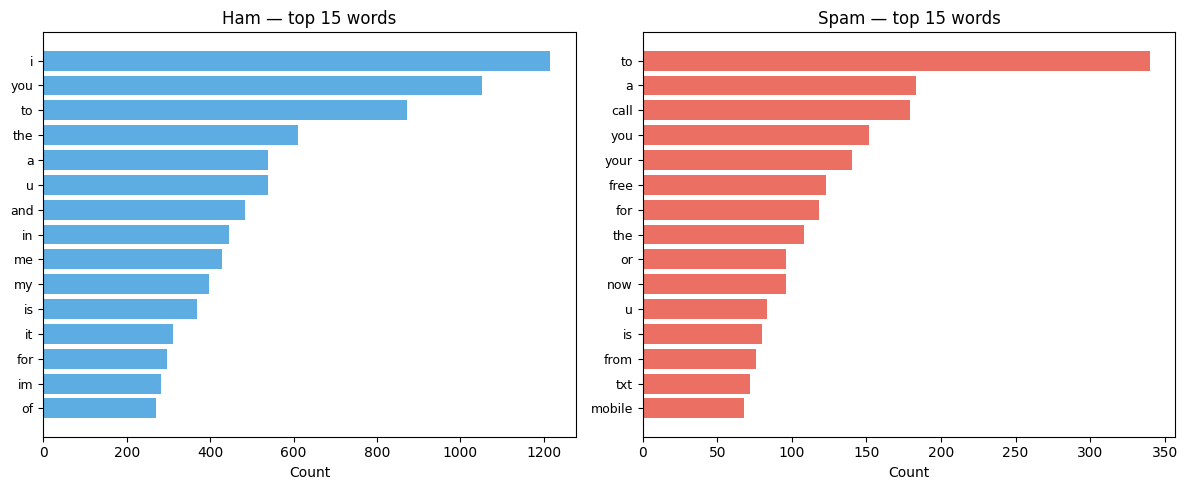

In [11]:
# Word frequency bar charts (top N words per class)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (title, top_list) in zip(axes, [("Ham — top " + str(TOP_N) + " words", top_ham), ("Spam — top " + str(TOP_N) + " words", top_spam)]):
    words = [w for w, _ in top_list]
    counts = [c for _, c in top_list]
    ax.barh(range(len(words)), counts, color='#3498db' if 'Ham' in title else '#e74c3c', alpha=0.8)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=9)
    ax.set_title(title)
    ax.set_xlabel("Count")
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

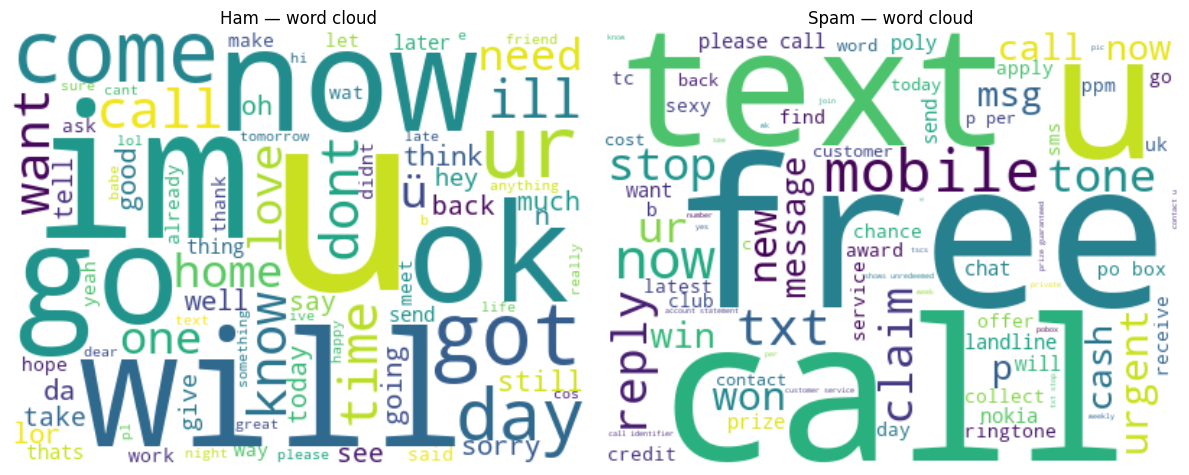

In [12]:
from wordcloud import WordCloud
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, cls, title in zip(axes, ['ham', 'spam'], ['Ham — word cloud', 'Spam — word cloud']):
    texts = df_train[df_train['Class'] == cls]['message_normalized'].dropna().str.cat(sep=' ')
    wc = WordCloud(width=400, height=300, background_color='white', max_words=80).generate(texts)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

#### Results of Step 2_3 & 2_4 : Top Words and Word Cloud Analysis

The analysis of the most frequent words and the corresponding word clouds reveals clear lexical differences between ham and spam messages.

- **Ham messages are dominated by conversational and personal language.**  
  Frequently occurring words such as *i, you, me, my, im, know, come,* and *got* indicate that ham messages are primarily informal, personal, and dialogue-oriented in nature.

- **Spam messages contain promotional and call-to-action vocabulary.**  
  In contrast, spam messages frequently include words such as *free, call, txt, mobile, prize, reply,* and *win*, which are commonly associated with advertisements, incentives, urgency, and automated messaging.

- **Distinct lexical patterns differentiate spam from ham messages.**  
  The word clouds visually emphasize this contrast: ham messages focus on everyday communication, whereas spam messages emphasize promotions, rewards, and immediate actions.

- **Presence of common words with different contextual roles.**  
  Some general-purpose words (e.g., *to, you, is*) appear in both classes; however, their surrounding context in spam messages often forms imperative or promotional phrases.

**Summary:**  
The observed lexical differences suggest that word-frequency–based features, such as Bag of Words or TF-IDF representations, are well-suited for distinguishing between spam and ham messages. These findings provide strong motivation for using text-based feature extraction techniques in the subsequent modeling phase.


### 2_5. Analyze frequency of special characters, numbers, URLs, etc.

Analyze how often **special characters** (e.g. punctuation, symbols), **digits/numbers**, and **URL-like patterns** appear in messages, and compare their distribution between ham and spam. Spam messages often contain more numbers, links, and promotional symbols (e.g. `!`, `$`, `FREE`), so these can be discriminative features.

In [13]:
import re
import string

# Use raw message if available (better for URLs/special chars), else normalized
msg_col = 'Message' if 'Message' in df_train.columns else 'message_normalized'
texts = df_train[msg_col].fillna('')

# Numeric and structural patterns

df_train['n_digits'] = texts.str.count(r'\d')
df_train['n_special'] = texts.apply(
    lambda s: sum(1 for c in str(s) if c in string.punctuation or (not c.isalnum() and not c.isspace()))
)

# URL-like patterns
url_pattern = re.compile(
    r'https?://|www\.|[a-zA-Z0-9-]+\.(?:com|org|net|co\.uk|info)\b',
    re.IGNORECASE
)
df_train['has_url'] = texts.str.contains(url_pattern).astype(int)
df_train['n_url_like'] = texts.str.findall(url_pattern).str.len().fillna(0).astype(int)

# Exclamation marks and currency symbols
df_train['n_exclamation'] = texts.str.count(r'!')
df_train['n_dollar'] = texts.str.count(r'\$')

# Urgency / promotional words

urgency_pattern = re.compile(r'\b(free|win|urgent)\b', re.IGNORECASE)

df_train['has_urgency_word'] = texts.str.contains(urgency_pattern).astype(int)
df_train['n_urgency_words'] = texts.str.findall(urgency_pattern).str.len().fillna(0).astype(int)


# Summary statistics by class

print("--- Frequency of special characters, numbers, URLs, and urgency words (by class) ---\n")

for feat in [
    'n_digits',
    'n_special',
    'n_url_like',
    'n_exclamation',
    'n_dollar',
    'n_urgency_words'
]:
    print(f"{feat}:")
    print(df_train.groupby('Class')[feat].agg(['mean', 'median', 'sum']).round(2))
    print()

print("Messages containing at least one URL-like pattern:")
print(df_train.groupby('Class')['has_url'].agg(['sum', 'mean']).round(4))

print("\nMessages containing at least one urgency word (FREE / WIN / URGENT):")
print(df_train.groupby('Class')['has_urgency_word'].agg(['sum', 'mean']).round(4))


--- Frequency of special characters, numbers, URLs, and urgency words (by class) ---

n_digits:
        mean  median   sum
Class                     
ham     0.28     0.0   748
spam   15.65    16.0  6027

n_special:
       mean  median    sum
Class                     
ham    3.81     3.0  10313
spam   6.06     6.0   2333

n_url_like:
       mean  median  sum
Class                   
ham    0.00     0.0    9
spam   0.36     0.0  137

n_exclamation:
       mean  median  sum
Class                   
ham    0.18     0.0  487
spam   0.69     0.0  266

n_dollar:
       mean  median  sum
Class                   
ham    0.00     0.0   13
spam   0.01     0.0    4

n_urgency_words:
       mean  median  sum
Class                   
ham    0.02     0.0   43
spam   0.49     0.0  188

Messages containing at least one URL-like pattern:
       sum    mean
Class             
ham      9  0.0033
spam    82  0.2130

Messages containing at least one urgency word (FREE / WIN / URGENT):
       sum    mean
C

C:\Users\ERAM\AppData\Local\Temp\ipykernel_15364\474740597.py:31: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_train['has_urgency_word'] = texts.str.contains(urgency_pattern).astype(int)


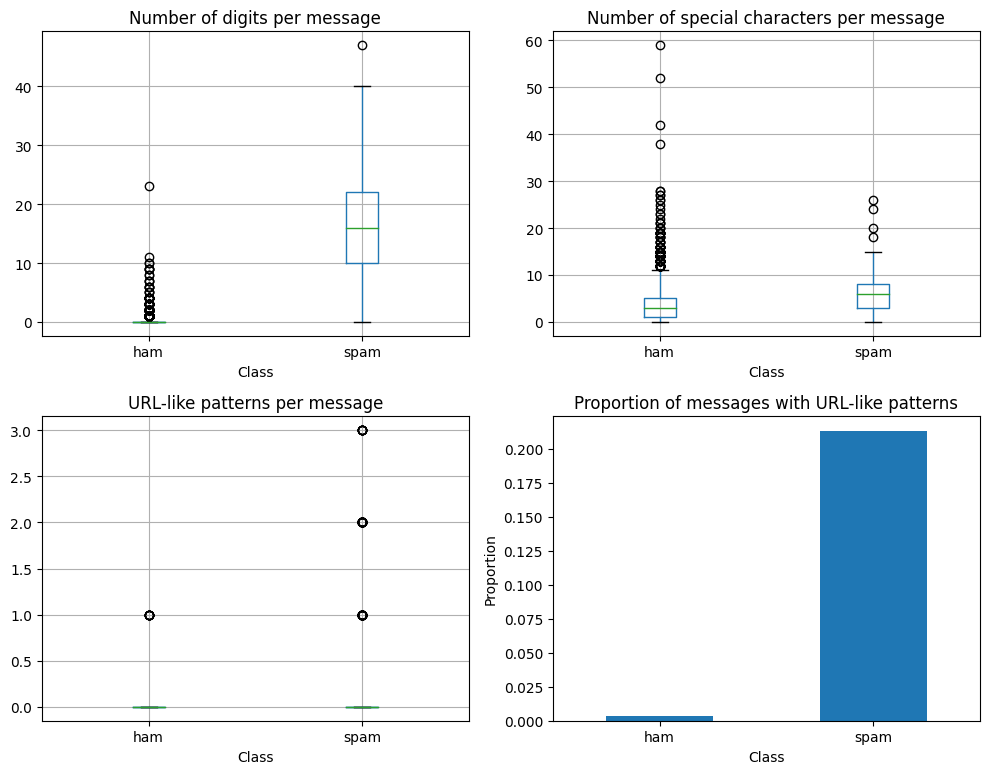

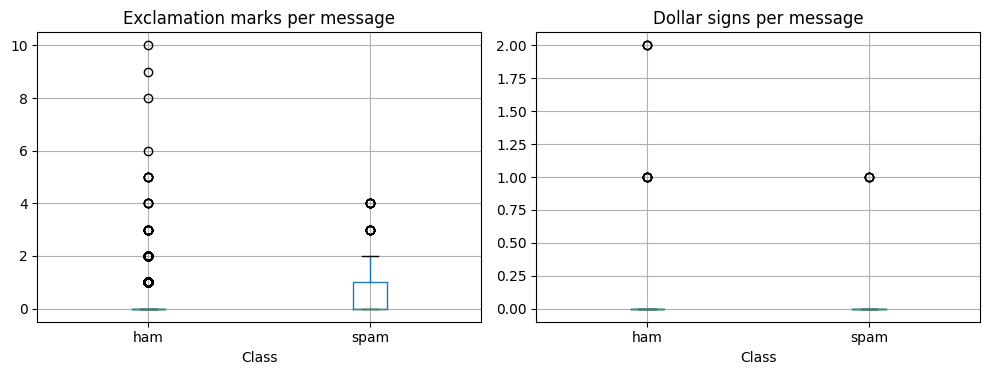

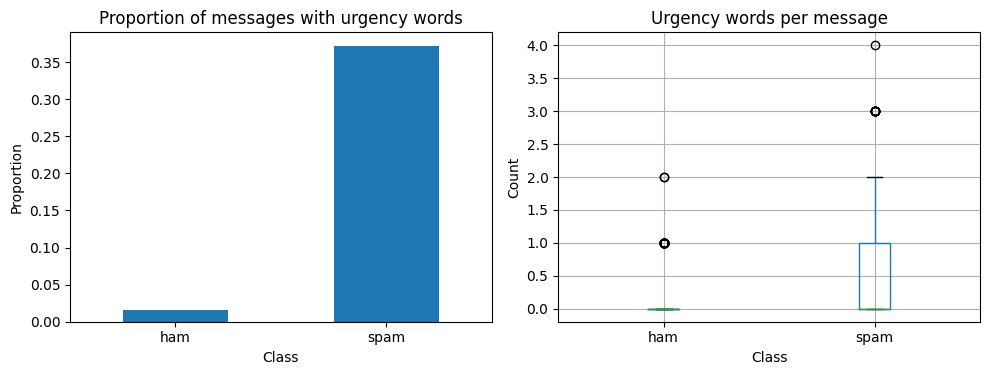

In [14]:
import matplotlib.pyplot as plt


# 1. Digits, Special Characters, and URL-like Patterns
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Number of digits per message
df_train.boxplot(column='n_digits', by='Class', ax=axes[0, 0])
axes[0, 0].set_title('Number of digits per message')
axes[0, 0].set_xlabel('Class')

# Number of special characters per message
df_train.boxplot(column='n_special', by='Class', ax=axes[0, 1])
axes[0, 1].set_title('Number of special characters per message')
axes[0, 1].set_xlabel('Class')

# URL-like pattern count per message
df_train.boxplot(column='n_url_like', by='Class', ax=axes[1, 0])
axes[1, 0].set_title('URL-like patterns per message')
axes[1, 0].set_xlabel('Class')

# Proportion of messages containing at least one URL-like pattern
url_by_class = df_train.groupby('Class')['has_url'].mean()
url_by_class.plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_title('Proportion of messages with URL-like patterns')
axes[1, 1].set_ylabel('Proportion')
axes[1, 1].set_xlabel('Class')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=0)

plt.suptitle('')
plt.tight_layout()
plt.show()


# 2. Exclamation Marks and Currency Symbols

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Exclamation marks
df_train.boxplot(column='n_exclamation', by='Class', ax=axes[0])
axes[0].set_title('Exclamation marks per message')
axes[0].set_xlabel('Class')

# Dollar signs
df_train.boxplot(column='n_dollar', by='Class', ax=axes[1])
axes[1].set_title('Dollar signs per message')
axes[1].set_xlabel('Class')

plt.suptitle('')
plt.tight_layout()
plt.show()


# 3. Urgency Words (FREE / WIN / URGENT) – Side by Side

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Proportion of messages containing urgency words
urgency_by_class = df_train.groupby('Class')['has_urgency_word'].mean()
urgency_by_class.plot(kind='bar', ax=axes[0])

axes[0].set_title('Proportion of messages with urgency words')
axes[0].set_ylabel('Proportion')
axes[0].set_xlabel('Class')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Number of urgency words per message
df_train.boxplot(column='n_urgency_words', by='Class', ax=axes[1])

axes[1].set_title('Urgency words per message')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')

plt.suptitle('')
plt.tight_layout()
plt.show()


#### Results of Step 2_5: Analyze Frequency of Structural Patterns

The analysis of structural patterns highlights clear differences between spam and ham messages.

- **Numeric content:**  
  Spam messages contain significantly more digits than ham messages, reflecting frequent use of phone numbers, prices, or promotional codes.

- **Special characters and punctuation:**  
  Spam messages exhibit higher usage of special characters and exclamation marks, indicating a more attention-grabbing and promotional style.

- **URLs and URL-like patterns:**  
  URLs are strongly associated with spam messages, with a substantially higher proportion of spam messages containing at least one URL-like pattern compared to ham messages.

- **Urgency-related words:**  
  Words such as *FREE*, *WIN*, and *URGENT* appear far more frequently in spam messages. Both the proportion of messages containing urgency words and the number of such words per message are notably higher for spam.

- **Currency symbols:**  
  Currency symbols occur more often in spam messages, although their overall frequency remains relatively low.

**Conclusion:**  
Overall, spam messages demonstrate distinct structural characteristics, including higher numeric content, frequent URLs, urgency-related language, and promotional punctuation. These features provide strong discriminative signals and are suitable for use in feature engineering and subsequent modeling stages.


### Step 2_6: Identify distinguishing features between spam and ham messages:

**Specific patterns (per PDF):** *Phone numbers* — We use the count of digits per message (`n_digits`) as a proxy for phone numbers (spam often contains many digits). *Currency symbols* — We use `n_dollar` (count of `$`) to capture currency/price mentions. Below: KDE of digit count by class; spam messages show a peak at higher digit counts.

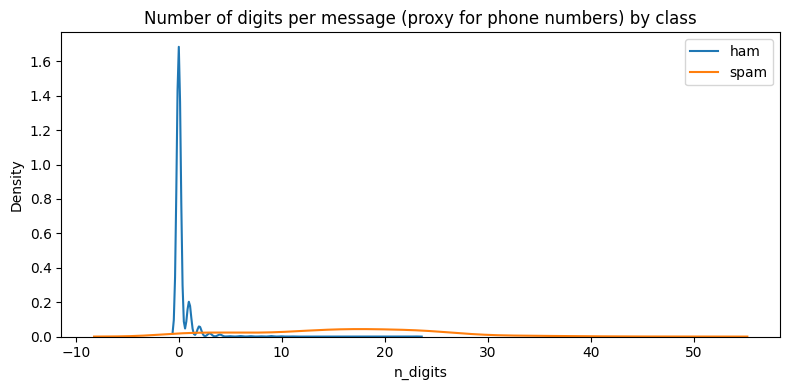

In [15]:
# KDE: number of digits per message (proxy for phone numbers) by class — spam peaks at higher digit counts
import seaborn as sns
fig, ax = plt.subplots(figsize=(8, 4))
for cls in ['ham', 'spam']:
    subset = df_train.loc[df_train['Class'] == cls, 'n_digits'].dropna()
    sns.kdeplot(subset, ax=ax, label=cls)
ax.set_title('Number of digits per message (proxy for phone numbers) by class')
ax.set_xlabel('n_digits')
ax.legend()
plt.tight_layout()
plt.show()

#### Step 2_6_1: Compare statistical differences (mean, median, variance) in message length, word count, and character frequencies between classes

- Spam messages have higher mean and median values for message length (characters) and word count.
- Ham messages show greater variance in message length and word count, indicating higher variability.
- Character-based features such as digits and special characters occur more frequently in spam messages.
- Ham messages generally contain very few numeric or special characters.


#### Step 2_6_2: Analyze presence and frequency of specific patterns (e.g., phone numbers,currency symbols, urgency words like "FREE", "WIN", "URGENT")


- Spam messages contain numeric patterns such as phone numbers more frequently than ham messages.
- Currency symbols appear more often in spam messages.
- Urgency-related words (e.g., FREE, WIN, URGENT) are significantly more common in spam messages.
- A higher proportion of spam messages contain at least one urgency word.
- Ham messages rarely include these promotional and urgency-related patterns.


#### Step 2_6_3: Use statistical tests (e.g., t-tests, chi-square tests) to identify features with significant differences between spam and ham

In [16]:
from scipy.stats import ttest_ind, chi2_contingency
import pandas as pd
import re
import string

if 'msg_len_chars' not in df_train.columns:
    df_train['msg_len_chars'] = df_train['Message'].apply(len)
if 'msg_len_words' not in df_train.columns:
    df_train['msg_len_words'] = df_train['tokens'].apply(len)

urgency_pattern = re.compile(r'\b(free|win|urgent|cash|prize)\b', re.IGNORECASE)
if 'has_urgency_word' not in df_train.columns:
    df_train['has_urgency_word'] = df_train['Message'].apply(lambda x: 1 if urgency_pattern.search(str(x)) else 0)

url_pattern = re.compile(r'https?://|www\.|[a-zA-Z0-9-]+\.(?:com|org|net|co\.uk|info)\b', re.IGNORECASE)
if 'has_url' not in df_train.columns:
    df_train['has_url'] = df_train['Message'].apply(lambda x: 1 if url_pattern.search(str(x)) else 0)

# A. Independent T-Tests 
numeric_features = [
    'msg_len_chars',
    'msg_len_words',
    'n_digits',
    'n_special',
    'n_exclamation',
    'n_dollar'
]

print("=== A. Independent T-Test Results (Numeric Features) ===")
print(f"{'Feature':<20} | {'T-Stat':<10} | {'P-Value':<12} | {'Significant?'}")
print("-" * 65)

ham = df_train[df_train['Class'] == 'ham']
spam = df_train[df_train['Class'] == 'spam']

existing_numeric = [col for col in numeric_features if col in df_train.columns]

for feat in existing_numeric:
    t_stat, p_val = ttest_ind(ham[feat], spam[feat], equal_var=False)
    
    sig = "YES ✅" if p_val < 0.05 else "NO ❌"
    print(f"{feat:<20} | {t_stat:10.2f} | {p_val:12.2e} | {sig}")


# B. Chi-Square Tests 
binary_features = [
    'has_url',
    'has_urgency_word'
]

print("\n=== B. Chi-Square Test Results (Binary Features) ===")
print(f"{'Feature':<20} | {'Chi2 Stat':<10} | {'P-Value':<12} | {'Significant?'}")
print("-" * 65)

existing_binary = [col for col in binary_features if col in df_train.columns]

for feat in existing_binary:
    contingency_table = pd.crosstab(df_train['Class'], df_train[feat])
    
    chi2, p_val, dof, expected = chi2_contingency(contingency_table)
    
    sig = "YES ✅" if p_val < 0.05 else "NO ❌"
    print(f"{feat:<20} | {chi2:10.2f} | {p_val:12.2e} | {sig}")

=== A. Independent T-Test Results (Numeric Features) ===
Feature              | T-Stat     | P-Value      | Significant?
-----------------------------------------------------------------
msg_len_chars        |     -30.24 |    1.47e-138 | YES ✅
msg_len_words        |     -21.91 |     6.58e-84 | YES ✅
n_digits             |     -33.44 |    5.55e-116 | YES ✅
n_special            |     -11.19 |     3.08e-26 | YES ✅
n_exclamation        |     -10.73 |     5.24e-24 | YES ✅
n_dollar             |      -1.03 |     3.03e-01 | NO ❌

=== B. Chi-Square Test Results (Binary Features) ===
Feature              | Chi2 Stat  | P-Value      | Significant?
-----------------------------------------------------------------
has_url              |     511.58 |    2.87e-113 | YES ✅
has_urgency_word     |     758.42 |    5.94e-167 | YES ✅


- Independent t-tests show statistically significant differences between spam and ham messages in message length (characters and words), number of digits, special characters, and exclamation marks (p < 0.05).
- The use of dollar symbols does not show a statistically significant difference between the two classes (p ≥ 0.05).
- Chi-square tests confirm a strong association between spam messages and the presence of URLs.
- Chi-square tests also show a statistically significant association between spam messages and urgency-related words (FREE, WIN, URGENT).
- Overall, most structural and lexical features exhibit significant differences between spam and ham messages.


#### Step 2_6_4: Create comparative visualizations (side-by-side comparisons, overlays) to highlight differences

In [17]:
# Explicit statistical summary table (mean, median, variance/std) by class — per PDF "Compare statistical differences"
stats_cols = ['msg_len_chars', 'msg_len_words', 'n_digits', 'n_special', 'n_exclamation', 'n_dollar']
stats_cols = [c for c in stats_cols if c in df_train.columns]
stat_summary = df_train.groupby('Class')[stats_cols].agg(['mean', 'median', 'std']).round(2)
print("Statistical summary (mean, median, std) by class — for report/table:")
display(stat_summary)

Statistical summary (mean, median, std) by class — for report/table:


msg_len_chars               msg_len_words               n_digits         \
               mean median    std          mean median    std     mean median   
Class                                                                           
ham           64.97   48.0  49.84         13.58   10.0  10.08     0.28    0.0   
spam         113.58  120.0  25.33         21.05   22.0   5.51    15.65   16.0   

            n_special              n_exclamation              n_dollar         \
        std      mean median   std          mean median   std     mean median   
Class                                                                           
ham    0.97      3.81    3.0  4.05          0.18    0.0  0.62     0.00    0.0   
spam   9.01      6.06    6.0  3.64          0.69    0.0  0.90     0.01    0.0   

             
        std  
Class        
ham    0.08  
spam   0.10

Side-by-side comparisons and overlay visualizations were created to highlight differences between spam and ham messages across multiple features, including message length, numeric content, special characters, URLs, and urgency-related patterns.


### Step 2_7: Correlation analysis (if applicable)

We compute the correlation matrix between numeric and count-based features to see how they relate to each other. This helps identify redundant features (high correlation) for feature selection in later phases.

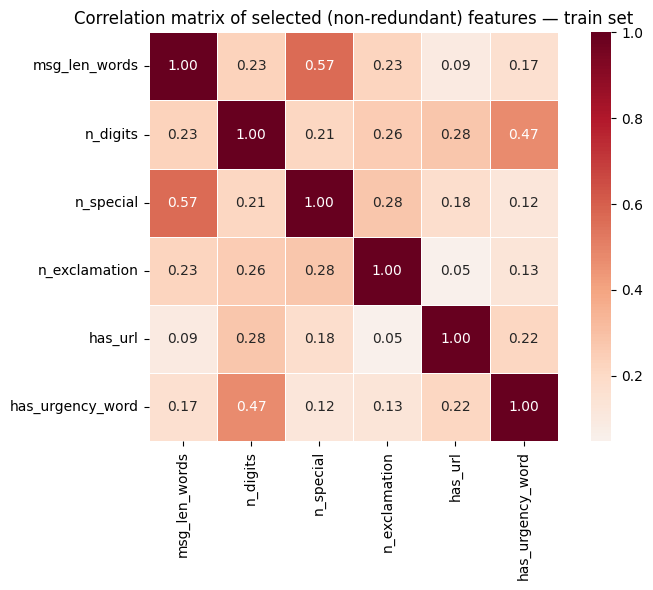

Notable correlations (|r| > 0.5):
  msg_len_words <-> n_special: r = 0.567


In [18]:
# Correlation analysis — reduced (non-redundant) feature set
import seaborn as sns
import matplotlib.pyplot as plt

selected_features = [
    'msg_len_words',     # representative of message length
    'n_digits',          # numeric content
    'n_special',         # special characters
    'n_exclamation',     # emphasis / promotion
    'has_url',           # presence of URL
    'has_urgency_word'   # promotional / urgency language
]

# Keep only existing columns (robust code)
existing_features = [c for c in selected_features if c in df_train.columns]

# Compute correlation matrix
df_corr = df_train[existing_features].corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    df_corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title(
    'Correlation matrix of selected (non-redundant) features — train set',
    fontsize=12
)
plt.tight_layout()
plt.show()

# Print notable correlations
print("Notable correlations (|r| > 0.5):")
for i in range(len(existing_features)):
    for j in range(i + 1, len(existing_features)):
        r = df_corr.iloc[i, j]
        if abs(r) > 0.5:
            print(f"  {existing_features[i]} <-> {existing_features[j]}: r = {r:.3f}")


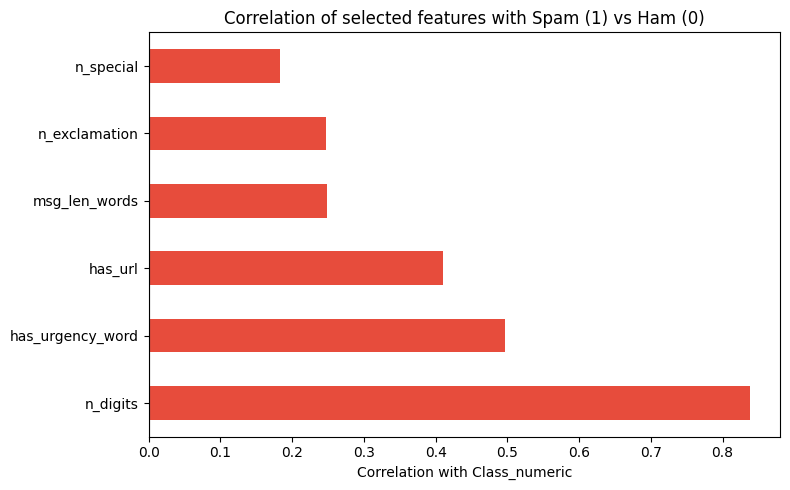

Correlation with Spam (Class_numeric):
n_digits            0.838
has_urgency_word    0.497
has_url             0.410
msg_len_words       0.248
n_exclamation       0.247
n_special           0.183
Name: Class_numeric, dtype: float64


In [19]:
import matplotlib.pyplot as plt

# Encode target: spam = 1, ham = 0
df_train['Class_numeric'] = (df_train['Class'] == 'spam').astype(int)

# Final selected (non-redundant) features
selected_features = [
    'msg_len_words',
    'n_digits',
    'n_special',
    'n_exclamation',
    'has_url',
    'has_urgency_word'
]

# Keep only columns that exist (robust)
features = [c for c in selected_features if c in df_train.columns]

# Correlation with target
corr_with_target = (
    df_train[features + ['Class_numeric']]
    .corr()['Class_numeric']
    .drop('Class_numeric')
)

# Sort by absolute correlation
corr_with_target = corr_with_target.reindex(
    corr_with_target.abs().sort_values(ascending=False).index
)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
corr_with_target.plot(
    kind='barh',
    ax=ax,
    color=['#e74c3c' if x > 0 else '#3498db' for x in corr_with_target]
)

ax.set_title('Correlation of selected features with Spam (1) vs Ham (0)')
ax.set_xlabel('Correlation with Class_numeric')
ax.axvline(0, color='gray', linewidth=0.8)

plt.tight_layout()
plt.show()

# Print values
print("Correlation with Spam (Class_numeric):")
print(corr_with_target.round(3))


### Results of Step 2_7: Correlation analysis

- Correlation with target (Spam): The correlation-with-target bar chart shows that numeric content (number of digits), the presence of URLs, and urgency-related words have the strongest positive correlation with spam messages. Message length also shows a positive correlation, though slightly weaker than these indicators.
- Message length (characters vs. words): A strong positive correlation is observed between character-based and word-based message length measures, indicating redundancy. Therefore, a single representative length feature can be sufficient for modeling.
- Digits, special characters, URLs, urgency: Positive correlations among these features are common in spam messages, reflecting typical promotional and contact-seeking patterns. Some pairs show moderate to high correlation, suggesting that a subset of these features may be selected to reduce redundancy.
- Implications for modeling: The observed correlations highlight potential multicollinearity among certain features. In Phase 04, this information can be used to perform informed feature selection by retaining representative features or applying regularization techniques.


### Step 2_8 : Document key insights and patterns


- Spam messages are generally longer and more uniform in structure than ham messages.
- Spam messages frequently contain numeric content, URLs, and urgency-related words.
- Ham messages are more variable in length and primarily contain conversational language.
- Statistical tests confirmed that most structural and lexical features differ significantly between spam and ham messages.
- These patterns indicate that both structural and lexical features are effective for distinguishing spam from ham messages.


### 2_9.Summary Report — Phase 02: Data Understanding & Visualization



This section summarizes all key tasks and deliverables of Phase 02 (EDA & Visualization).

| Topic | Status | Action taken |
|--------|--------|------------------|
| **Class distribution (spam vs. ham ratio)** | Done | Analyzed and printed counts; bar chart of class distribution; ratio (ham/spam) reported. |
| **Message length distribution (characters, words)** | Done | Histogram and box plot for message length (chars and words) by class; summary stats (mean, median, std) by class. |
| **Most common words (spam vs. ham)** | Done | Top N words per class using tokens; word frequency bar charts for ham and spam. |
| **Word clouds (spam and ham)** | Done | Word clouds generated for ham and spam messages from normalized text. |
| **Frequency of special characters, numbers, URLs** | Done | Counts for digits, special characters, URL-like patterns, exclamation marks, currency symbols; urgency words (FREE, WIN, URGENT); visualizations and summary by class. |
| **Distinguishing features — statistical differences** | Done | Compared mean, median, variance in message length, word count, and character-based features between classes (Step 2_6_1). |
| **Distinguishing features — specific patterns** | Done | Analyzed presence/frequency of phone-like numbers, currency symbols, urgency words (Step 2_6_2). |
| **Statistical tests (t-test, chi-square)** | Done | Independent t-tests for numeric features; chi-square for binary (has_url, has_urgency_word); significant features reported (Step 2_6_3). |
| **Comparative visualizations** | Done | Side-by-side and overlay plots for length, digits, special chars, URLs, urgency words (Step 2_6_4). |
| **Correlation analysis** | Done | Correlation matrix and heatmap of numeric/count features; brief interpretation for feature selection (Step 2_6_5). |
| **Document key insights and patterns** | Done | Markdown “Results” and summaries after each step; final insights on discriminative features for modeling. |

**Visualizations included:** Bar chart (class distribution), Histogram (message length by class), Box plot (message length comparison), Word frequency charts (top N words per class), Word clouds (spam vs. ham), Analysis of special characters/numbers/URLs frequency.